In [7]:
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [8]:
tickers = ["SPY", "GLD", "XLF", "XLK", "XLE", "IVV", "QQQ", "BND"]

all_data = []

for ticker in tickers:
    etf = yf.Ticker(ticker)
    hist = etf.history(period="2y")
    hist["Ticker"] = ticker
    hist.reset_index(inplace=True)
    all_data.append(hist)

df = pd.concat(all_data)
df.to_csv("etf_raw_data.csv", index=False)
print(f"Data fetched! Total rows: {len(df)}")
df.head()

Data fetched! Total rows: 4008


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Ticker
0,2024-05-09 00:00:00-04:00,505.087710,507.850489,504.433645,507.811401,43643700,0.0,0.0,0.0,SPY
1,2024-05-10 00:00:00-04:00,509.412410,510.222707,507.245183,508.465485,52233200,0.0,0.0,0.0,SPY
2,2024-05-13 00:00:00-04:00,510.144574,510.251946,507.391567,508.533752,36716400,0.0,0.0,0.0,SPY
3,2024-05-14 00:00:00-04:00,508.729064,511.384471,508.192143,510.867035,57535900,0.0,0.0,0.0,SPY
4,2024-05-15 00:00:00-04:00,513.337011,517.486037,512.702430,517.193176,59504900,0.0,0.0,0.0,SPY


## **DATA CLEANING**

In [9]:
# Keep relevant columns
df = df[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]

# Fix date format
df["Date"] = pd.to_datetime(df["Date"]).dt.date

# Drop nulls and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Add daily return %
df["Daily_Return_%"] = df.groupby("Ticker")["Close"].pct_change() * 100
df["Daily_Return_%"] = df["Daily_Return_%"].round(2)

# Add Month & Year
df["Month"] = pd.to_datetime(df["Date"]).dt.strftime("%b-%Y")
df["Year"] = pd.to_datetime(df["Date"]).dt.year

df.to_csv("etf_clean_data.csv", index=False)
print(f"Cleaned! Rows remaining: {len(df)}")
df.head()

Cleaned! Rows remaining: 4008


,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return_%,Month,Year
0,2024-05-09,SPY,505.087710,507.850489,504.433645,507.811401,43643700,NaN,May-2024,2024
1,2024-05-10,SPY,509.412410,510.222707,507.245183,508.465485,52233200,0.13,May-2024,2024
2,2024-05-13,SPY,510.144574,510.251946,507.391567,508.533752,36716400,0.01,May-2024,2024
3,2024-05-14,SPY,508.729064,511.384471,508.192143,510.867035,57535900,0.46,May-2024,2024
4,2024-05-15,SPY,513.337011,517.486037,512.702430,517.193176,59504900,1.24,May-2024,2024


# **KPI ANALYSIS**

In [10]:
# Average closing price
avg_price = df.groupby("Ticker")["Close"].mean().round(2).rename("Avg_Close_Price")

# Total volume
total_volume = df.groupby("Ticker")["Volume"].sum().rename("Total_Volume")

# Average daily return
avg_return = df.groupby("Ticker")["Daily_Return_%"].mean().round(3).rename("Avg_Daily_Return_%")

# Volatility
volatility = df.groupby("Ticker")["Daily_Return_%"].std().round(3).rename("Volatility_%")

# Latest price
latest_price = df.sort_values("Date").groupby("Ticker")["Close"].last().round(2).rename("Latest_Price")

# Combine
kpi_df = pd.concat([avg_price, total_volume, avg_return, volatility, latest_price], axis=1)
kpi_df.reset_index(inplace=True)

kpi_df.to_csv("etf_kpi_summary.csv", index=False)
print(kpi_df)

  Ticker  Avg_Close_Price  Total_Volume  Avg_Daily_Return_%  Volatility_%  \
0    BND            70.62    3523297500               0.021         0.292   
1    GLD           312.23    5378183400               0.149         1.433   
2    IVV           608.88    3378300500               0.080         1.023   
3    QQQ           537.44   22658378800               0.107         1.340   
4    SPY           606.46   32994590500               0.080         1.051   
5    XLE            44.80   17624767200               0.056         1.434   
6    XLF            48.74   21217127400               0.053         1.112   
7    XLK           123.92    6494538700               0.124         1.632   

   Latest_Price  
0         73.55  
1        433.77  
2        740.97  
3        711.23  
4        737.62  
5         55.70  
6         51.24  
7        175.52  


# **VISUALISATIONS**

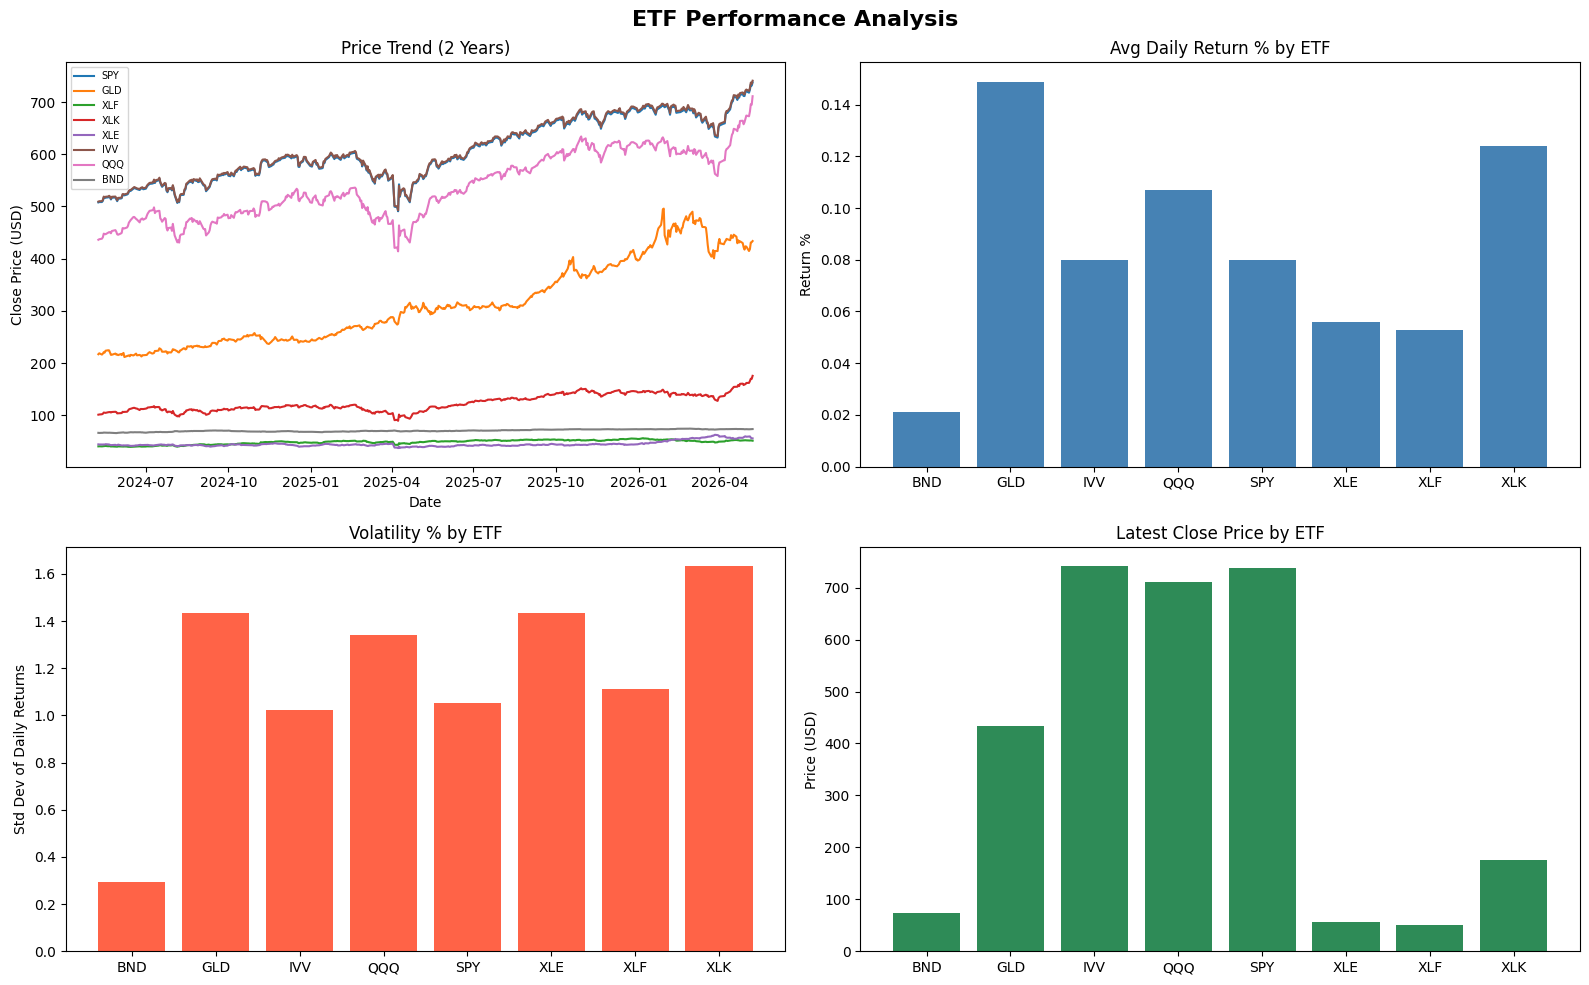

Charts saved!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("ETF Performance Analysis", fontsize=16, fontweight="bold")

# 1. Price trend for all ETFs
for ticker in tickers:
    subset = df[df["Ticker"] == ticker]
    axes[0, 0].plot(pd.to_datetime(subset["Date"]), subset["Close"], label=ticker)
axes[0, 0].set_title("Price Trend (2 Years)")
axes[0, 0].legend(fontsize=7)
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Close Price (USD)")

# 2. Average daily return
axes[0, 1].bar(kpi_df["Ticker"], kpi_df["Avg_Daily_Return_%"], color="steelblue")
axes[0, 1].set_title("Avg Daily Return % by ETF")
axes[0, 1].set_ylabel("Return %")

# 3. Volatility comparison
axes[1, 0].bar(kpi_df["Ticker"], kpi_df["Volatility_%"], color="tomato")
axes[1, 0].set_title("Volatility % by ETF")
axes[1, 0].set_ylabel("Std Dev of Daily Returns")

# 4. Latest price comparison
axes[1, 1].bar(kpi_df["Ticker"], kpi_df["Latest_Price"], color="seagreen")
axes[1, 1].set_title("Latest Close Price by ETF")
axes[1, 1].set_ylabel("Price (USD)")

plt.tight_layout()
plt.savefig("etf_charts.png", dpi=150)
plt.show()
print("Charts saved!")

**LOAD EXCEL FOR POWERBI VISUALISATION**

In [12]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment

with pd.ExcelWriter("ETF_Performance_Report.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Raw Data", index=False)
    kpi_df.to_excel(writer, sheet_name="KPI Summary", index=False)

    pivot = df.pivot_table(
        values="Close",
        index="Month",
        columns="Ticker",
        aggfunc="mean"
    ).round(2)
    pivot.to_excel(writer, sheet_name="Monthly Avg Price")

print("Excel report saved! Download from the Files panel on the left.")

Excel report saved! Download from the Files panel on the left.
